In [1]:
!pip install sacrebleu evaluate openpyxl wordcloud matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import gc, re, random, unicodedata
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
from transformers import NllbTokenizer, AutoModelForSeq2SeqLM
import sacrebleu

random.seed(42)
np.random.seed(42)

# ── Paths ──
DATA_DIR   = Path("/kaggle/input/datasets/alexkorablev/qom-corpus")

# Bible model outputs (attach notebooks qom-mt-bible-es2qom and qom-mt-bible-qom2es)
BIBLE_ES2QOM = Path("/kaggle/input/notebooks/alexkorablev/qom-mt-bible-es2qom/qom-nllb/best-es2qom")
BIBLE_QOM2ES = Path("/kaggle/input/notebooks/alexkorablev/qom-mt-bible-qom2es/qom-nllb/best-qom2es")

# V1-strat model outputs (attach notebook qom-mt-v1-strat)
V1_ES2QOM    = Path("/kaggle/input/notebooks/alexkorablev/qom-mt-v1-strat/qom-nllb-v1/best-es2qom")
V1_QOM2ES    = Path("/kaggle/input/notebooks/alexkorablev/qom-mt-v1-strat/qom-nllb-v1/best-qom2es")

OUT_DIR = Path("/kaggle/working/ablation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SRC_LANG = "spa_Latn"
TGT_LANG = "grn_Latn"
MAX_NEW_TOKENS = 128

print("Config OK")
for p in [BIBLE_ES2QOM, BIBLE_QOM2ES, V1_ES2QOM, V1_QOM2ES]:
    print(f"  {'OK' if p.exists() else 'MISSING'} {p}")

Config OK
  OK /kaggle/input/notebooks/alexkorablev/qom-mt-bible-es2qom/qom-nllb/best-es2qom
  OK /kaggle/input/notebooks/alexkorablev/qom-mt-bible-qom2es/qom-nllb/best-qom2es
  OK /kaggle/input/notebooks/alexkorablev/qom-mt-v1-strat/qom-nllb-v1/best-es2qom
  OK /kaggle/input/notebooks/alexkorablev/qom-mt-v1-strat/qom-nllb-v1/best-qom2es


In [3]:
# ── Rebuild v1 test split (same logic + seed as training notebooks) ──────────
import re as _re

def read_workbook(path):
    doc_name = path.stem
    xl = pd.ExcelFile(path)
    frames = []
    for sheet in xl.sheet_names:
        try:
            raw = xl.parse(sheet)
        except Exception:
            continue
        raw.columns = [str(c).strip() for c in raw.columns]
        if "linea_qom" not in raw.columns or "linea_es" not in raw.columns:
            continue
        sub = raw[["linea_qom", "linea_es"]].copy()
        sub.columns = ["qom", "es"]
        for meta_q, meta_e, id_col in [
            ("nombre_capitulo_qom","nombre_capitulo_es","id_capitulo"),
            ("nombre_seccion_qom","nombre_seccion_es","id_seccion"),
            ("nombre_fragmento_qom","nombre_fragmento_es","id_fragmento"),
        ]:
            if meta_q in raw.columns and meta_e in raw.columns:
                m = raw[[meta_q, meta_e]].dropna().copy()
                m.columns = ["qom","es"]
                m[id_col] = np.nan
                sub = pd.concat([sub, m], ignore_index=True)
        for col in ["id_linea","id_fragmento","id_seccion","id_capitulo"]:
            if col not in sub.columns:
                sub[col] = raw.get(col, np.nan)
        sub["source_doc"]  = doc_name
        sub["source_path"] = str(path)
        sub["sheet_name"]  = sheet
        frames.append(sub)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

xlsx_files = sorted(DATA_DIR.glob("*.xlsx"))
df = pd.concat([read_workbook(p) for p in xlsx_files], ignore_index=True)

# El Principito CSV (v1 includes it)
pp = DATA_DIR / "El Principito.csv"
if pp.exists():
    raw = pd.read_csv(pp)
    raw.columns = [str(c).strip() for c in raw.columns]
    sub = raw[["qom","espanol"]].copy()
    sub.columns = ["qom","es"]
    sub = sub.dropna().query('qom != "" and es != "" and qom != "nan" and es != "nan"')
    sub["id_linea"]     = [f"el_principito_{i+1}" for i in range(len(sub))]
    sub["id_fragmento"] = np.nan
    sub["id_seccion"]   = np.nan
    sub["id_capitulo"]  = np.nan
    sub["source_doc"]   = "El Principito"
    sub["source_path"]  = str(pp)
    sub["sheet_name"]   = "csv"
    df = pd.concat([df, sub], ignore_index=True)

# QC
_tok = _re.compile(r"\w+|[^\w\s]", _re.UNICODE)
def ntok(s): return len([t for t in _tok.findall(str(s)) if t.strip()])
df = df.dropna(subset=["qom","es"])
df["qom"] = df["qom"].astype(str).str.strip()
df["es"]  = df["es"].astype(str).str.strip()
df = df[(df["qom"] != "") & (df["es"] != "") &
        (df["qom"] != "nan") & (df["es"] != "nan")]
df["ql"] = df["qom"].map(ntok)
df["el"] = df["es"].map(ntok)
df["lr"] = (df["el"]+1)/(df["ql"]+1)
df = df[(df["ql"]>=2)&(df["el"]>=2)&(df["lr"]>=0.2)&(df["lr"]<=5)]
df = df.drop_duplicates(subset=["qom","es"])
df = df.drop(columns=["ql","el","lr"])

# Assign group IDs
def gid(row):
    for col, tag in [("id_fragmento","frag"),("id_seccion","sec"),("id_capitulo","cap")]:
        if pd.notna(row.get(col)):
            return f"{row['source_doc']}__{tag}__{row[col]}"
    return str(row["source_doc"])
df["group_id"] = df.apply(gid, axis=1)

# Nostrat split (random) — same seed
from sklearn.model_selection import train_test_split
groups = df["group_id"].unique()
train_g, temp_g = train_test_split(groups, test_size=0.20, random_state=42)
dev_g,   test_g = train_test_split(temp_g,  test_size=0.50, random_state=42)
test_df_nostrat = df[df["group_id"].isin(test_g)].reset_index(drop=True)

# Strat split — same seed
from sklearn.model_selection import GroupShuffleSplit
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
idx_train, idx_temp = next(gss1.split(df, groups=df["group_id"]))
temp = df.iloc[idx_temp]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
_, idx_test = next(gss2.split(temp, groups=temp["group_id"]))
test_df_strat = temp.iloc[idx_test].reset_index(drop=True)

print(f"Test set (strat)  : {len(test_df_strat)} pairs")
print(f"Test set (nostrat): {len(test_df_nostrat)} pairs")
print(f"Sources in strat test: {test_df_strat['source_doc'].value_counts().to_dict()}")

Test set (strat)  : 158 pairs
Test set (nostrat): 485 pairs
Sources in strat test: {'Arte verbal qom': 107, 'Materiales del Taller de Lengua y Cultura Toba': 29, 'Educacion Sanitaria Intercultural': 22}


In [4]:
# ── Inference helper ─────────────────────────────────────────────────────────
def load_model(model_path):
    tok   = NllbTokenizer.from_pretrained(str(model_path), local_files_only=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(str(model_path), local_files_only=True)
    model.eval()
    if torch.cuda.is_available():
        model = model.cuda()
    return tok, model

def translate_batch(texts, tok, model, src_lang, tgt_lang, batch_size=16):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tok.src_lang = src_lang
        enc = tok(batch, return_tensors="pt", padding=True,
                  truncation=True, max_length=128)
        if torch.cuda.is_available():
            enc = {k: v.cuda() for k, v in enc.items()}
        with torch.no_grad():
            out = model.generate(
                **enc,
                forced_bos_token_id=tok.convert_tokens_to_ids(tgt_lang),
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=4,
            )
        results.extend(tok.batch_decode(out, skip_special_tokens=True))
    return results

def chrf(hypotheses, references):
    return sacrebleu.corpus_chrf(hypotheses, [references]).score

In [5]:
# ── Run ablation: QOM → ES ───────────────────────────────────────────────────
test_df = test_df_strat.copy()

qom_sentences = test_df["qom"].tolist()
ref_es        = test_df["es"].tolist()

print("Loading V1-strat QOM→ES model...")
tok_v1, model_v1 = load_model(V1_QOM2ES)
hyp_v1 = translate_batch(qom_sentences, tok_v1, model_v1, TGT_LANG, SRC_LANG)
score_v1 = chrf(hyp_v1, ref_es)
print(f"  ChrF++ V1 (no Bible) QOM→ES: {score_v1:.2f}")
del model_v1; gc.collect(); torch.cuda.empty_cache()

print("Loading Bible QOM→ES model...")
tok_bi, model_bi = load_model(BIBLE_QOM2ES)
hyp_bi = translate_batch(qom_sentences, tok_bi, model_bi, TGT_LANG, SRC_LANG)
score_bi = chrf(hyp_bi, ref_es)
print(f"  ChrF++ Bible QOM→ES: {score_bi:.2f}")
del model_bi; gc.collect(); torch.cuda.empty_cache()

print(f"\nDrop from Bible dominance: {score_v1 - score_bi:.2f} ChrF++ points")

Loading V1-strat QOM→ES model...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ChrF++ V1 (no Bible) QOM→ES: 30.88
Loading Bible QOM→ES model...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ChrF++ Bible QOM→ES: 20.31

Drop from Bible dominance: 10.56 ChrF++ points


In [6]:
# ── Run ablation: ES → QOM ───────────────────────────────────────────────────
es_sentences = test_df["es"].tolist()
ref_qom      = test_df["qom"].tolist()

print("Loading V1-strat ES→QOM model...")
tok_v1, model_v1 = load_model(V1_ES2QOM)
hyp_v1_e2q = translate_batch(es_sentences, tok_v1, model_v1, SRC_LANG, TGT_LANG)
score_v1_e2q = chrf(hyp_v1_e2q, ref_qom)
print(f"  ChrF++ V1 (no Bible) ES→QOM: {score_v1_e2q:.2f}")
del model_v1; gc.collect(); torch.cuda.empty_cache()

print("Loading Bible ES→QOM model...")
tok_bi, model_bi = load_model(BIBLE_ES2QOM)
hyp_bi_e2q = translate_batch(es_sentences, tok_bi, model_bi, SRC_LANG, TGT_LANG)
score_bi_e2q = chrf(hyp_bi_e2q, ref_qom)
print(f"  ChrF++ Bible ES→QOM: {score_bi_e2q:.2f}")
del model_bi; gc.collect(); torch.cuda.empty_cache()

print(f"\nDrop from Bible dominance: {score_v1_e2q - score_bi_e2q:.2f} ChrF++ points")

Loading V1-strat ES→QOM model...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ChrF++ V1 (no Bible) ES→QOM: 38.25
Loading Bible ES→QOM model...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ChrF++ Bible ES→QOM: 33.78

Drop from Bible dominance: 4.46 ChrF++ points


In [7]:
# ── Save 4-column CSV ────────────────────────────────────────────────────────
out = pd.DataFrame({
    "qom":              qom_sentences,
    "es_reference":     ref_es,
    "es_v1_no_bible":   hyp_v1,
    "es_bible_only":    hyp_bi,
})
csv_path = OUT_DIR / "ablation_qom2es.csv"
out.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}  ({len(out)} rows)")

out_e2q = pd.DataFrame({
    "es":               es_sentences,
    "qom_reference":    ref_qom,
    "qom_v1_no_bible":  hyp_v1_e2q,
    "qom_bible_only":   hyp_bi_e2q,
})
csv_path_e2q = OUT_DIR / "ablation_es2qom.csv"
out_e2q.to_csv(csv_path_e2q, index=False)
print(f"Saved: {csv_path_e2q}  ({len(out_e2q)} rows)")

Saved: /kaggle/working/ablation/ablation_qom2es.csv  (158 rows)
Saved: /kaggle/working/ablation/ablation_es2qom.csv  (158 rows)


 rank     word_v1  count_v1 word_bible  count_bible
    1     paredes        93      comen           10
    2    parásito        66      puede           10
    3   indicador        52      lugar            8
    4     árboles        48     lengua            8
    5        agua        46  convierta            8
    6    formando        35       león            7
    7       tobas        30      árbol            7
    8     estaban        27        río            7
    9         sol        26       agua            7
   10       donde        20      dicen            6
   11       dulce        19      corta            6
   12    entonces        14      huevo            6
   13       tenés        14       mano            6
   14       hacer        14       caso            6
   15    volcanes        14    llamado            6
   16       vacas        12  manantial            6
   17       color        12    quienes            5
   18 amarillento        12      donde            5
   19     pá

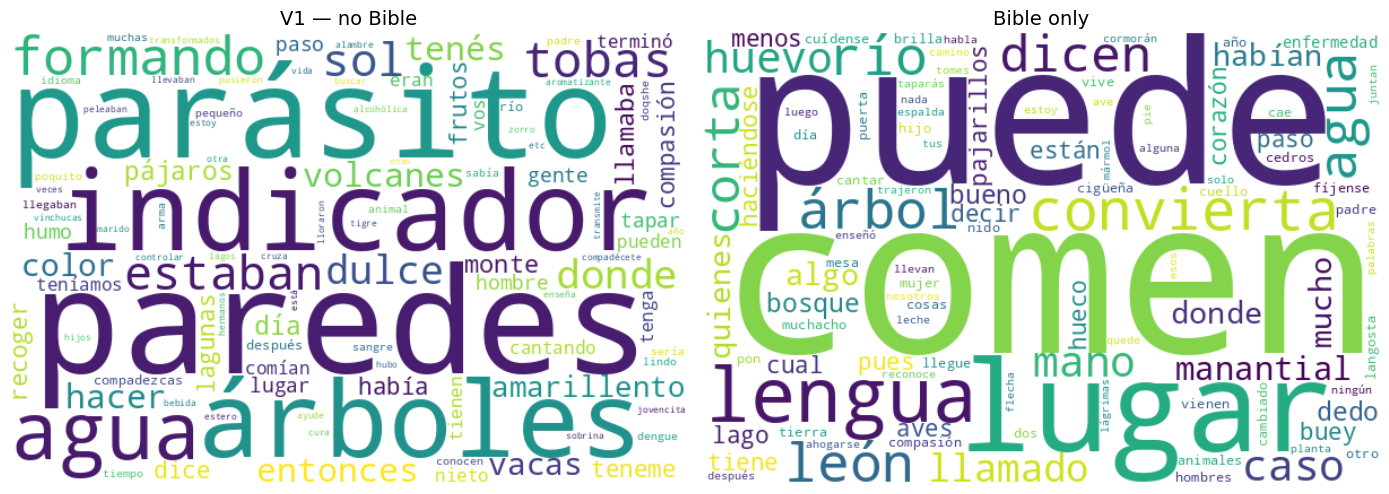

Saved: /kaggle/working/ablation/wordcloud_qom2es.png


In [8]:
# ── Word frequency analysis (QOM→ES, Spanish output) ────────────────────────
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import defaultdict
from nltk.stem import SnowballStemmer
import nltk
nltk.download("punkt_tab", quiet=True)

STOPWORDS_ES = {
    "de","la","el","en","y","a","que","se","los","las","un","una","con",
    "no","lo","es","su","al","del","por","le","me","te","nos","les",
    "más","si","pero","ya","o","era","han","hay","fue","ser","son",
    "como","cuando","para","esto","esta","este","eso","esa","ese",
    "sus","él","ella","ellos","ellas","yo","tú","tu","mi","mis",
    "también","todo","todos","toda","todas","muy","bien","así",
    "porque","entre","hasta","desde","sobre","sin","ni","e","u",
    "unos","unas","an","has","have","the","le","les","nos","os",
}

stemmer = SnowballStemmer("spanish")

def top_words(texts, n=100):
    """
    Count word frequencies with Spanish stemming so inflected forms
    (e.g. parásito/parásitos, árbol/árboles) are merged.
    The most frequent surface form for each stem is used for display.
    """
    stem_counts  = Counter()
    stem_surface = defaultdict(Counter)
    for t in texts:
        for w in re.findall(r"\b[a-záéíóúüñ]+\b", t.lower()):
            if w in STOPWORDS_ES or len(w) <= 2:
                continue
            stem = stemmer.stem(w)
            stem_counts[stem] += 1
            stem_surface[stem][w] += 1
    result = []
    for stem, count in stem_counts.most_common(n):
        best_form = stem_surface[stem].most_common(1)[0][0]
        result.append((best_form, count))
    return result

top_v1 = top_words(hyp_v1)
top_bi = top_words(hyp_bi)

# Comparison table: top 20
n = min(20, len(top_v1), len(top_bi))
df_freq = pd.DataFrame({
    "rank":        range(1, n+1),
    "word_v1":     [w for w,_ in top_v1[:n]],
    "count_v1":    [c for _,c in top_v1[:n]],
    "word_bible":  [w for w,_ in top_bi[:n]],
    "count_bible": [c for _,c in top_bi[:n]],
})
freq_path = OUT_DIR / "word_freq_top20.csv"
df_freq.to_csv(freq_path, index=False)
print(df_freq.to_string(index=False))

# Word clouds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, freqs, title in [
    (axes[0], dict(top_v1), "V1 — no Bible"),
    (axes[1], dict(top_bi), "Bible only"),
]:
    if freqs:
        wc = WordCloud(width=600, height=400, background_color="white").generate_from_frequencies(freqs)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

plt.tight_layout()
wc_path = OUT_DIR / "wordcloud_qom2es.png"
plt.savefig(wc_path, dpi=150)
plt.show()
print(f"Saved: {wc_path}")


In [9]:
# ── Summary ──────────────────────────────────────────────────────────────────
print("="*60)
print("  ABLATION RESULTS")
print("="*60)
print(f"  QOM→ES  V1 (no Bible) : {score_v1:.2f} ChrF++")
print(f"  QOM→ES  Bible only    : {score_bi:.2f} ChrF++")
print(f"  ES→QOM  V1 (no Bible) : {score_v1_e2q:.2f} ChrF++")
print(f"  ES→QOM  Bible only    : {score_bi_e2q:.2f} ChrF++")
print()
print(f"  Outputs saved to: {OUT_DIR}")
print(f"    ablation_qom2es.csv")
print(f"    ablation_es2qom.csv")
print(f"    word_freq_top20.csv")
print(f"    wordcloud_qom2es.png")

  ABLATION RESULTS
  QOM→ES  V1 (no Bible) : 30.88 ChrF++
  QOM→ES  Bible only    : 20.31 ChrF++
  ES→QOM  V1 (no Bible) : 38.25 ChrF++
  ES→QOM  Bible only    : 33.78 ChrF++

  Outputs saved to: /kaggle/working/ablation
    ablation_qom2es.csv
    ablation_es2qom.csv
    word_freq_top20.csv
    wordcloud_qom2es.png
